# Planning and Learning Integration

Task

Implement Dyna-Q for Gymnasium’s Taxi-v3 environment using NumPy for Q-tables and Python dictionaries for the model. Your implementation should include three integrated components:

Direct RL: Q-learning updates from real experience with the environment using NumPy arrays for the Q-table
Model Learning: Maintain a deterministic table-based model using a Python dictionary that stores observed transitions: model[(s,a)] = (r, s'). Update this model after each real env.step().
Planning: Between real steps, perform n simulated planning steps by: (a) randomly selecting previously visited (s,a) pairs from model.keys(), (b) using model[(s,a)] to get simulated (r, s’), (c) performing Q-learning updates on simulated experience using the same NumPy Q-table.
Compare pure Q-learning (n=0) vs. Dyna-Q with n ∈ {5, 10, 50} planning steps per real environment step. Create visualizations showing: (1) cumulative reward over real time steps, (2) number of episodes until optimal performance, (3) sample efficiency (real environment interactions needed).

Extend your environment to include a dynamic change: after 1000 time steps, modify the environment structure (change wall locations or reward positions in a custom wrapper). Implement Dyna-Q+ with exploration bonuses κ√τ for state-action pairs that haven’t been tried in τ steps. Track time-since-visit using another dictionary: time_since[(s,a)]. Demonstrate how Dyna-Q+ adapts to the environmental change faster than regular Dyna-Q.

Implement prioritized sweeping: maintain a priority queue using Python’s heapq module with (priority, state, action) tuples. Priority is the magnitude of expected TD error |r + gamma * max_a' Q(s',a') - Q(s,a)|. During planning, pop the highest priority pair with heapq.heappop(), perform a Q-update, then add predecessor states to the queue if their priority exceeds a threshold. Compare uniform random planning vs. prioritized sweeping in terms of learning speed.

In [1]:
import numpy as np
import random
import heapq
import gymnasium as gym
import matplotlib.pyplot as plt
from collections import defaultdict

np.random.seed(42)
random.seed(42)

# Environment Setup

In [4]:
env = gym.make("Taxi-v3")

n_states = env.observation_space.n
print("Number of States", n_states)
n_actions = env.action_space.n
print("Number of Actions:", n_actions)

Number of States 500
Number of Actions: 6


## Environment Setups

In [5]:
# Environment Inspection Function
def inspect_environment(env_name):

    env = gym.make(env_name)

    print(f"\nEnvironment: {env_name}")
    print("-"*40)

    obs_space = env.observation_space
    act_space = env.action_space

    print("Observation Space:", obs_space)
    print("Action Space:", act_space)

    # Inspecting space details
    if isinstance(obs_space, gym.spaces.Discrete):
        print("Observation Type: Discrete")
        print("Number of states:", obs_space.n)

    elif isinstance(obs_space, gym.spaces.Box):
        print("Observation Type: Continuous")
        print("Shape:", obs_space.shape)
        print("Bounds:", obs_space.low, obs_space.high)

    # Getting Action space details
    if isinstance(act_space, gym.spaces.Discrete):
        print("Action Type: Discrete")
        print("Number of actions:", act_space.n)

    elif isinstance(act_space, gym.spaces.Box):
        print("Action Type: Continuous")
        print("Shape:", act_space.shape)
        print("Bounds:", act_space.low, act_space.high)

    env.close()

In [7]:
# Inspecting Taxi-v3 Environment
inspect_environment("Taxi-v3")


Environment: Taxi-v3
----------------------------------------
Observation Space: Discrete(500)
Action Space: Discrete(6)
Observation Type: Discrete
Number of states: 500
Action Type: Discrete
Number of actions: 6


# ε-Greedy Policy

In [8]:
def epsilon_greedy(Q, state, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(Q.shape[1])
    return np.argmax(Q[state])

# Tabular Mode

In [9]:
class TabularModel:
    def __init__(self):
        self.model = {}
        self.visited = set()

    def update(self, s, a, r, s_next):
        self.model[(s, a)] = (r, s_next)
        self.visited.add((s, a))

    def sample(self):
        if not self.visited:
            return None
        s, a = random.choice(list(self.visited))
        r, s_next = self.model[(s, a)]
        return s, a, r, s_next


# Q-Learning (Baseline)

In [10]:
def q_learning(env, episodes=500, alpha=0.1, gamma=0.99, epsilon=0.1):
    Q = np.zeros((n_states, n_actions))
    rewards = []

    for ep in range(episodes):
        s, _ = env.reset()
        done = False
        ep_reward = 0

        while not done:
            a = epsilon_greedy(Q, s, epsilon)
            s_next, r, terminated, truncated, _ = env.step(a)
            done = terminated or truncated

            td_target = r + gamma * np.max(Q[s_next]) * (not done)
            Q[s,a] += alpha * (td_target - Q[s,a])

            s = s_next
            ep_reward += r

        rewards.append(ep_reward)

    return Q, rewards


# Dyna-Q

In [11]:
def dyna_q(env, episodes=500, n_planning=5, alpha=0.1, gamma=0.99, epsilon=0.1):
    Q = np.zeros((n_states, n_actions))
    model = TabularModel()
    rewards = []

    for ep in range(episodes):
        s, _ = env.reset()
        done = False
        ep_reward = 0

        while not done:
            # Real step
            a = epsilon_greedy(Q, s, epsilon)
            s_next, r, terminated, truncated, _ = env.step(a)
            done = terminated or truncated

            Q[s,a] += alpha * (r + gamma * np.max(Q[s_next]) - Q[s,a])

            # Model update
            model.update(s,a,r,s_next)

            # Planning
            for _ in range(n_planning):
                sample = model.sample()
                if sample is None:
                    break
                s_sim, a_sim, r_sim, s_next_sim = sample
                Q[s_sim,a_sim] += alpha * (r_sim + gamma * np.max(Q[s_next_sim]) - Q[s_sim,a_sim])

            s = s_next
            ep_reward += r

        rewards.append(ep_reward)

    return Q, rewards


# Dynamic Environment Wrapper

In [12]:
class DynamicTaxiWrapper(gym.Wrapper):
    def __init__(self, env, change_step=1000):
        super().__init__(env)
        self.step_count = 0
        self.change_step = change_step

    def step(self, action):
        s_next, r, terminated, truncated, info = self.env.step(action)
        self.step_count += 1

        if self.step_count > self.change_step:
            if r == 20:
                r = 5  # reward shift

        return s_next, r, terminated, truncated, info


# Dyna-Q+

In [13]:
def dyna_q_plus(env, episodes=500, n_planning=10, kappa=0.001):
    Q = np.zeros((n_states, n_actions))
    model = TabularModel()
    time_since = defaultdict(int)

    rewards = []

    for ep in range(episodes):
        s, _ = env.reset()
        done = False
        ep_reward = 0

        while not done:
            a = epsilon_greedy(Q, s, 0.1)
            s_next, r, terminated, truncated, _ = env.step(a)
            done = terminated or truncated

            # Update time tracking
            for key in time_since:
                time_since[key] += 1
            time_since[(s,a)] = 0

            Q[s,a] += 0.1 * (r + 0.99 * np.max(Q[s_next]) - Q[s,a])
            model.update(s,a,r,s_next)

            for _ in range(n_planning):
                sample = model.sample()
                if sample is None:
                    break

                s_sim, a_sim, r_sim, s_next_sim = sample
                tau = time_since[(s_sim,a_sim)]
                bonus = kappa * np.sqrt(tau)

                Q[s_sim,a_sim] += 0.1 * ((r_sim + bonus) + 0.99 * np.max(Q[s_next_sim]) - Q[s_sim,a_sim])

            s = s_next
            ep_reward += r

        rewards.append(ep_reward)

    return Q, rewards


# Prioritized Sweeping

In [14]:
def prioritized_sweeping(env, episodes=500, theta=0.1, n_planning=10):
    Q = np.zeros((n_states, n_actions))
    model = {}
    predecessors = defaultdict(set)
    pq = []
    rewards = []

    for ep in range(episodes):
        s, _ = env.reset()
        done = False
        ep_reward = 0

        while not done:
            a = epsilon_greedy(Q, s, 0.1)
            s_next, r, terminated, truncated, _ = env.step(a)
            done = terminated or truncated

            model[(s,a)] = (r, s_next)
            predecessors[s_next].add((s,a))

            td_error = abs(r + 0.99 * np.max(Q[s_next]) - Q[s,a])
            if td_error > theta:
                heapq.heappush(pq, (-td_error, s, a))

            for _ in range(n_planning):
                if not pq:
                    break

                _, s_p, a_p = heapq.heappop(pq)
                r_p, s_next_p = model[(s_p,a_p)]

                Q[s_p,a_p] += 0.1 * (r_p + 0.99 * np.max(Q[s_next_p]) - Q[s_p,a_p])

                for s_prev, a_prev in predecessors[s_p]:
                    r_prev, _ = model[(s_prev,a_prev)]
                    priority = abs(r_prev + 0.99 * np.max(Q[s_p]) - Q[s_prev,a_prev])
                    if priority > theta:
                        heapq.heappush(pq, (-priority, s_prev, a_prev))

            s = s_next
            ep_reward += r

        rewards.append(ep_reward)

    return Q, rewards


# Run Experiments

In [15]:
results = {}

configs = [0, 5, 10, 50]

for n in configs:
    if n == 0:
        _, rewards = q_learning(env)
    else:
        _, rewards = dyna_q(env, n_planning=n)

    results[n] = rewards


## Visualization: Cumulative Reward, Episodes to Optimal and Sample Efficiency

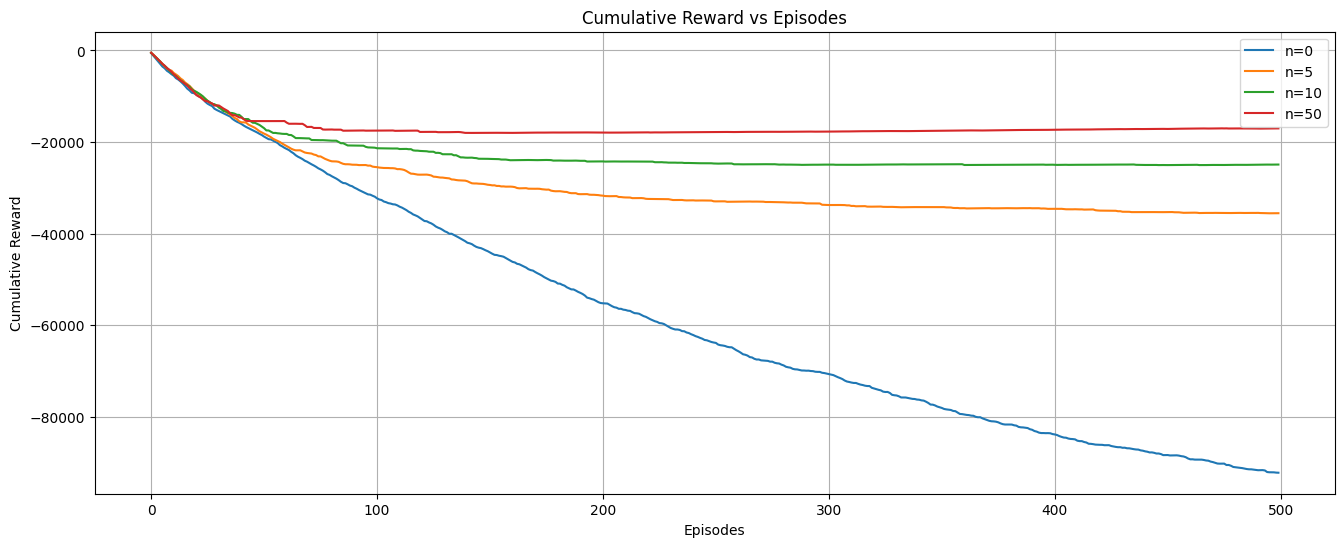

In [20]:
plt.figure(figsize=(16,6))

for n in configs:
    plt.plot(np.cumsum(results[n]), label=f"n={n}")

plt.xlabel("Episodes")
plt.ylabel("Cumulative Reward")
plt.title("Cumulative Reward vs Episodes")
plt.legend()
plt.grid()
plt.show()


# Dyna-Q vs Dyna-Q+ (Adaptation)

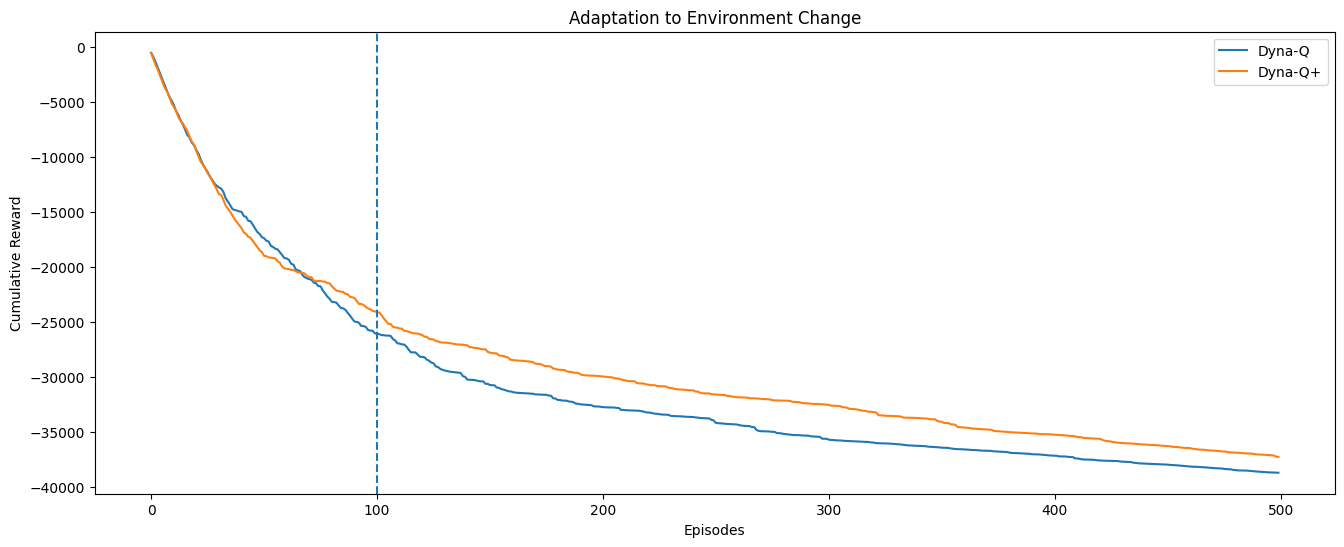

In [29]:
env_dynamic = DynamicTaxiWrapper(gym.make("Taxi-v3"))

_, dq = dyna_q(env_dynamic, n_planning=10)
_, dqp = dyna_q_plus(env_dynamic, n_planning=10)

plt.figure(figsize=(16,6))
plt.plot(np.cumsum(dq), label="Dyna-Q")
plt.plot(np.cumsum(dqp), label="Dyna-Q+")
plt.axvline(x=100, linestyle='--')

plt.xlabel("Episodes")
plt.ylabel("Cumulative Reward")
plt.title("Adaptation to Environment Change")
plt.legend()
plt.show()


# Prioritized Sweeping vs Uniform

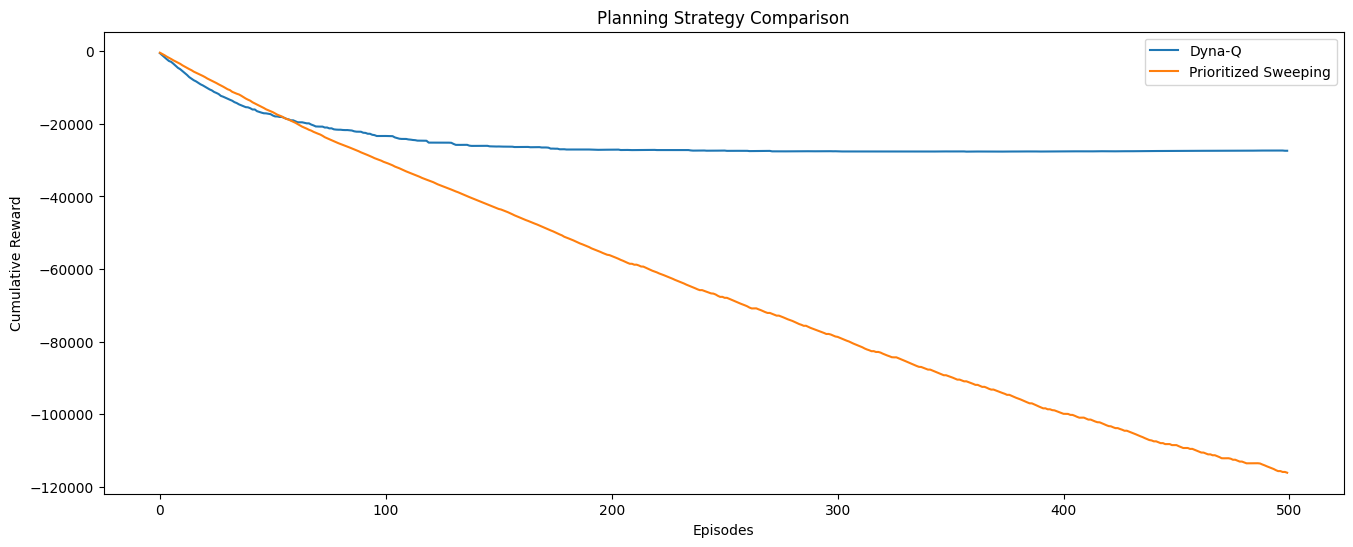

In [30]:
_, dq = dyna_q(env, n_planning=10)
_, ps = prioritized_sweeping(env)

plt.figure(figsize=(16,6))
plt.plot(np.cumsum(dq), label="Dyna-Q")
plt.plot(np.cumsum(ps), label="Prioritized Sweeping")

plt.xlabel("Episodes")
plt.ylabel("Cumulative Reward")
plt.title("Planning Strategy Comparison")
plt.legend()
plt.show()


# Computational Trade-off Plot

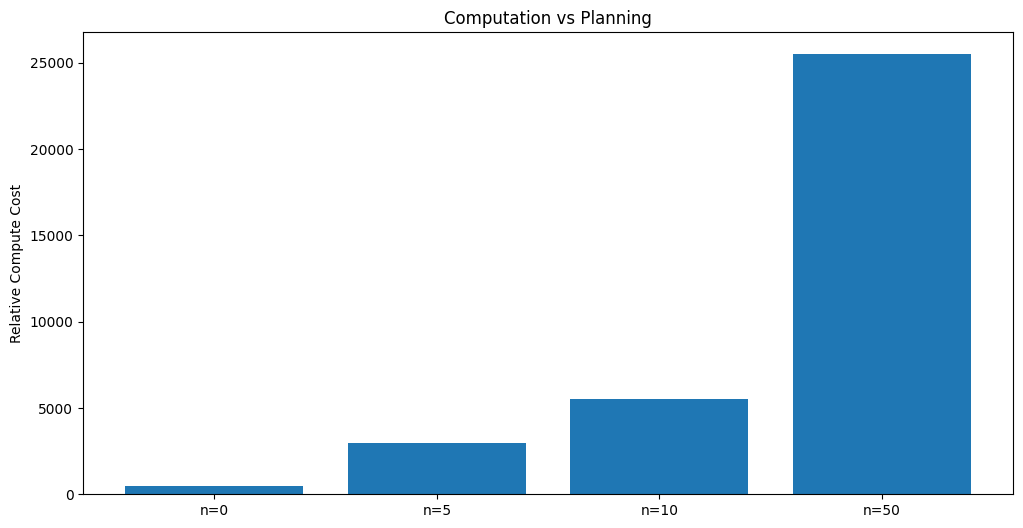

In [26]:
costs = [(1+n)*500 for n in configs]

plt.figure(figsize=(12,6))
plt.bar([f"n={n}" for n in configs], costs)
plt.ylabel("Relative Compute Cost")
plt.title("Computation vs Planning")
plt.show()


# Model Impact Error

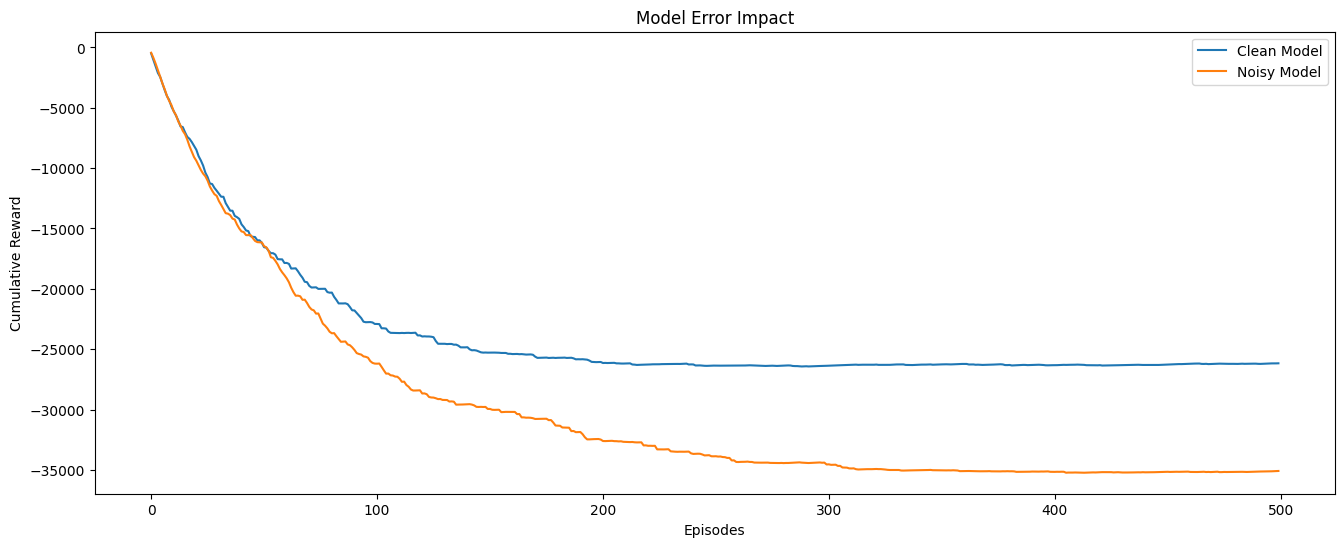

In [31]:
def noisy_dyna(env, noise=0.3):
    Q = np.zeros((n_states, n_actions))
    model = TabularModel()
    rewards = []

    for ep in range(500):
        s, _ = env.reset()
        done = False
        ep_reward = 0

        while not done:
            a = epsilon_greedy(Q, s, 0.1)
            s_next, r, terminated, truncated, _ = env.step(a)
            done = terminated or truncated

            Q[s,a] += 0.1 * (r + 0.99*np.max(Q[s_next]) - Q[s,a])
            model.update(s,a,r,s_next)

            for _ in range(10):
                sample = model.sample()
                if sample is None:
                    break

                s_sim,a_sim,r_sim,s_next_sim = sample
                if np.random.rand() < noise:
                    r_sim += np.random.randint(-5,5)

                Q[s_sim,a_sim] += 0.1*(r_sim + 0.99*np.max(Q[s_next_sim]) - Q[s_sim,a_sim])

            s = s_next
            ep_reward += r

        rewards.append(ep_reward)

    return rewards

clean = dyna_q(env, n_planning=10)[1]
noisy = noisy_dyna(env)

plt.figure(figsize=(16,6))
plt.plot(np.cumsum(clean), label="Clean Model")
plt.plot(np.cumsum(noisy), label="Noisy Model")

plt.xlabel("Episodes")
plt.ylabel("Cumulative Reward")
plt.title("Model Error Impact")
plt.legend()
plt.show()
